Shape: (440, 8)
<class 'pandas.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


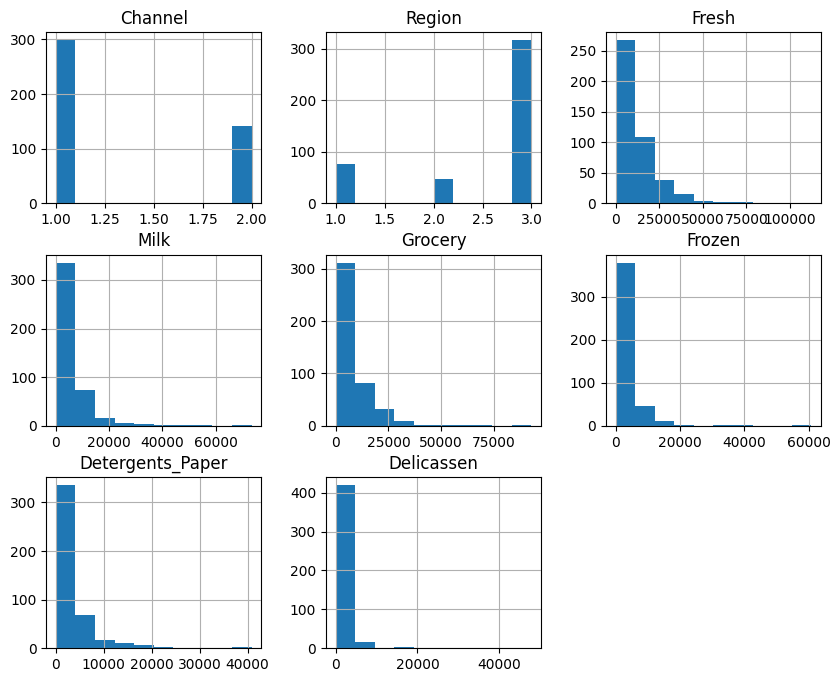

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Wholesale_customers_data.csv")
print(f'Shape: {df.shape}')
df.head()
df.info()
df.describe()
df.isnull().sum()

df.hist(figsize=(10,8))
plt.show()

***Correlation heatmap***

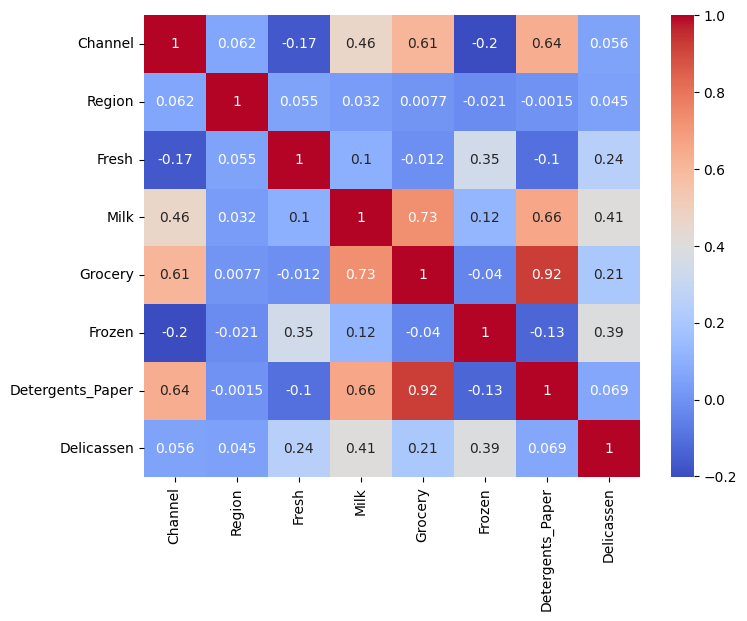

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

***Data Preprocessing***

In [20]:
#Drop Categorical Variable
df_clean = df.drop(['Channel', 'Region'], axis=1)

In [21]:
#Handle skewness
df_log = np.log1p(df_clean)

In [22]:
#Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_log)

In [23]:
#K-Means Clustering
from sklearn.cluster import KMeans

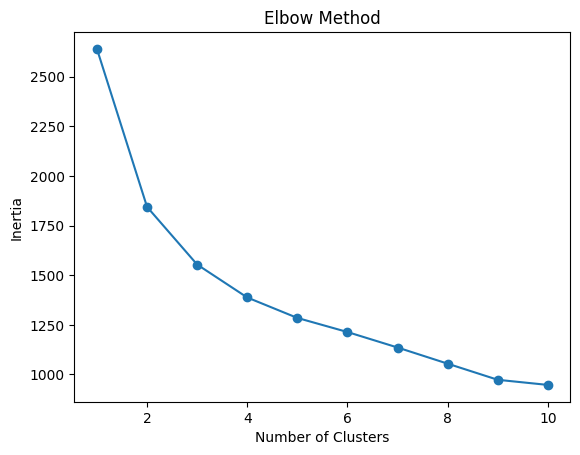

In [24]:
#Elbow Method

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [25]:
#Silhouette Score
from sklearn.metrics import silhouette_score

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    print(f"K={k}, Silhouette Score={score}")

K=2, Silhouette Score=0.2904884403725676
K=3, Silhouette Score=0.2607155784408494
K=4, Silhouette Score=0.18514346533341078
K=5, Silhouette Score=0.19165609775268222
K=6, Silhouette Score=0.17762325479526006
K=7, Silhouette Score=0.16877431378639335
K=8, Silhouette Score=0.19708350389592988
K=9, Silhouette Score=0.19650108536770935
K=10, Silhouette Score=0.19599855929618182


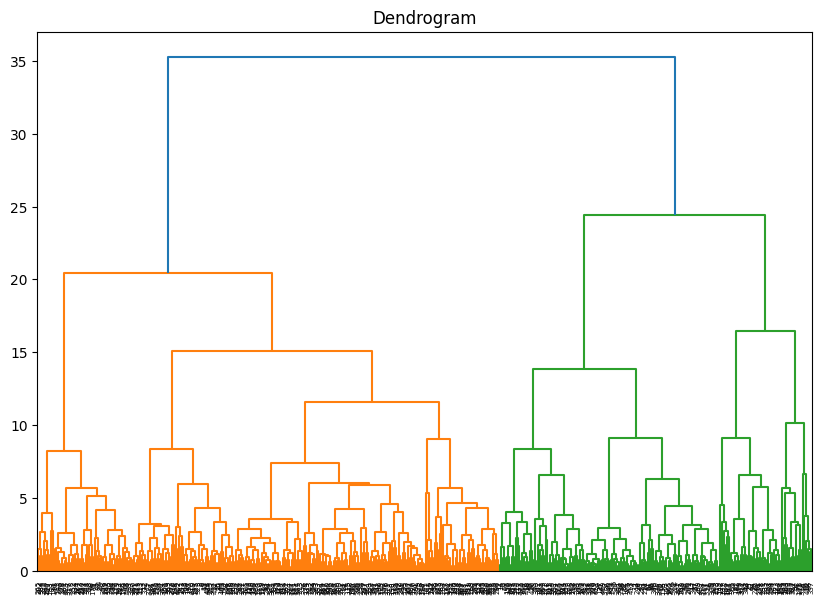

In [26]:
#Hierarchical Clustering

from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(df_scaled, method='ward')

plt.figure(figsize=(10,7))
dendrogram(linked)
plt.title("Dendrogram")
plt.show()

In [44]:
#with Hierarchical 3 clusters are possible but with many ouliners
# #DBSCAN
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.5, min_samples=5)
db_labels = db.fit_predict(df_scaled)

print("Unique labels:", set(db_labels))

Unique labels: {np.int64(0), np.int64(-1)}


In [38]:
#DBSCAN shows 1 Clusters and some outliners
#Considering KMeans and Hierarchical Clustering - 3 Clusters

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(df_scaled)

df_clean['Cluster'] = clusters

In [39]:
#Cluster Profiling
cluster_profile = df_clean.groupby('Cluster').mean()
print(cluster_profile)

                Fresh          Milk       Grocery       Frozen  \
Cluster                                                          
0         2809.444444   6945.901235  12232.567901   588.123457   
1        12399.537037   2087.828704   2554.074074  3286.509259   
2        16603.258741  10746.629371  13678.629371  4154.727273   

         Detergents_Paper   Delicassen  
Cluster                                 
0             5382.851852   782.345679  
1              427.435185   919.439815  
2             5171.468531  2859.958042  


In [40]:
#PCA Visualization
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

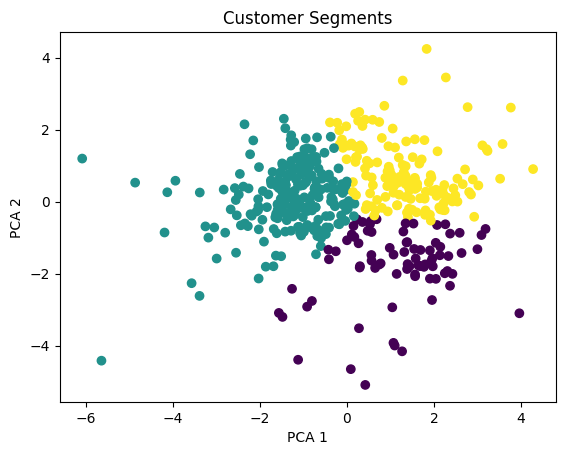

In [41]:
plt.scatter(pca_data[:,0], pca_data[:,1], c=clusters, cmap='viridis')
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Customer Segments")
plt.show()